# Librerías

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from urllib.request import urlopen
from skimage.feature import hog
from skimage import exposure
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Conjunto de datos

Se construyó un conjunto de datos compuesto por 40 imágenes, distribuidas en dos clases: 20 correspondientes a sentadillas y 20 a flexiones de pecho. Las imágenes fueron seleccionadas optando por incluir variaciones en la posición del cuerpo, el ángulo de captura y la perspectiva, con el fin de representar el movimiento desde diferentes direcciones. Esto permite capturar una mayor diversidad de características visuales y mejorar la capacidad del modelo frente a distintas condiciones.

Total imágenes: 40


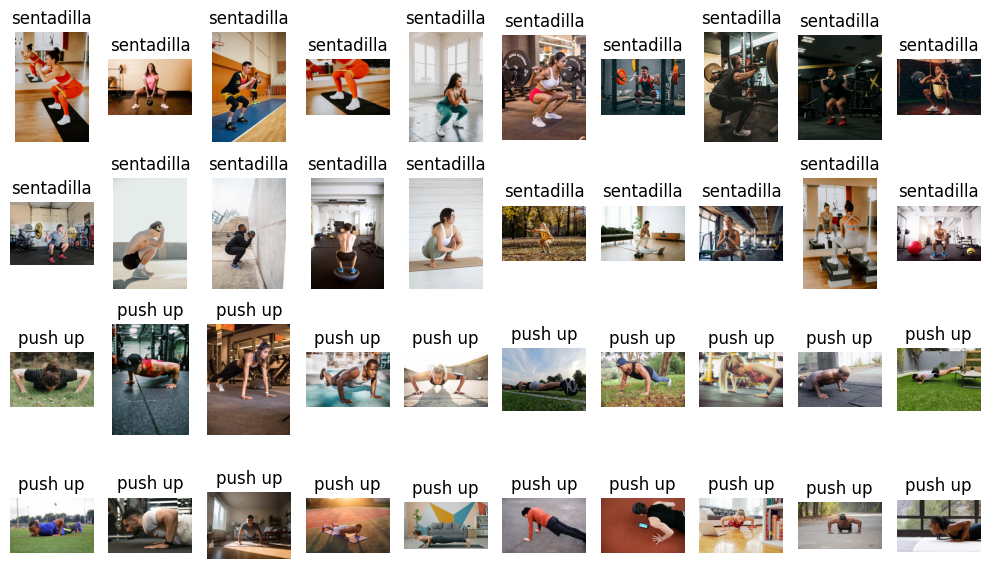

In [16]:
np.random.seed(42)

# (puede cambiar/añadir)
sentadillas = [
    "https://plus.unsplash.com/premium_photo-1666736569069-79c1789adf52?q=80&w=688&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1603503363848-6952525df449?q=80&w=1169&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1675364965052-fdb98d1ddd67?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1666736569066-1b51689fac70?q=80&w=1169&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1649887974297-4be052375a67?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1718633561231-864a4c466991?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTd8fGFpciUyMHNxdWF0fGVufDB8fDB8fHww",
    "https://images.unsplash.com/photo-1541600383005-565c949cf777?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTExfHxhaXIlMjBzcXVhdHxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1646072508462-a802209a16f3?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTE0fHxhaXIlMjBzcXVhdHxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1654906546323-ceb7ee0d699b?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTY0fHxhaXIlMjBzcXVhdHxlbnwwfHwwfHx8MA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1665203477453-0a9d0e0ae2b0?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1513352098199-8ccf457b35a8?q=80&w=1074&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1649878974657-81fd06097742?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1661438165787-dca9da5b88e2?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8OTd8fGhvbWJyZSUyMGhhY2llbmRvJTIwYWlyJTIwc3F1YXR8ZW58MHx8MHx8fDA%3D",
    "https://plus.unsplash.com/premium_photo-1663134028905-17e4b80c5162?q=80&w=679&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1767611118992-b300c4fb4bee?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTE3fHxzZW50YWRpbGxhfGVufDB8fDB8fHww",
    "https://media.istockphoto.com/id/2193062720/es/foto/un-viejo-deportista-activo-haciendo-sentadillas-en-la-naturaleza.webp?a=1&b=1&s=612x612&w=0&k=20&c=dxdIIAru61IAZ_qdF0K7R5gdN4QlbS0O7mQDVycU9M0=",
    "https://media.istockphoto.com/id/2206452955/es/foto/joven-mujer-asi%C3%A1tica-hermosa-haciendo-ejercicio-aer%C3%B3bico-en-casa-chica-atractiva-haciendo.webp?a=1&b=1&s=612x612&w=0&k=20&c=BFomBm9ez5V99pUq3SyZZbVrwrpJTiowEMNfs4WBXO0=",
    "https://media.istockphoto.com/id/2216625500/es/foto/atleta-femenina-feliz-haciendo-sentadillas-mientras-entrena-con-pesas-en-un-gimnasio.webp?a=1&b=1&s=612x612&w=0&k=20&c=-PJVqlPGSCoiHRPGeHgPfRbRiKjb1eVNjBuMOOen0B8=",
    "https://plus.unsplash.com/premium_photo-1666736569549-c106f7921d87?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8OTJ8fHNlbnRhZGlsbGF8ZW58MHx8MHx8fDA%3D",
    "https://plus.unsplash.com/premium_photo-1663134039867-4c39cb97fe65?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTY0fHxzZW50YWRpbGxhfGVufDB8fDB8fHww"
]

flexionpecho = [
    "https://plus.unsplash.com/premium_photo-1664538541993-762eb39c6b40?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1598971639058-fab3c3109a00?q=80&w=701&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1718633625616-e5f297177a26?q=80&w=736&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1616803689943-5601631c7fec?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1663036507091-5d37013776c2?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1638820858482-800bd51f63f1?q=80&w=1074&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1683192943220-d191b72a4fac?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1661382496028-31fcde90200f?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1666956838556-f940185abbbf?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1599744331048-d58b430fb098?q=80&w=1076&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1600677396341-16965cbe9224?q=80&w=1169&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1764426445448-95103b0024a6?q=80&w=1167&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1760084081757-6f918c08403b?q=80&w=1025&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1663012894269-7a0840cc108a?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTA1fHxwdXNoJTIwdXBzJTIwdmlzdGElMjBkZXNkZSUyMGFycmliYXxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1758599878868-52cced2f8154?q=80&w=1332&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1673210887551-1b3dac70ef6d?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1712762001147-7f3d8bff3002?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MjY0fHxmbGV4aW9uJTIwZGUlMjBwZWNob3xlbnwwfHwwfHx8MA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1663045350901-80e9577dbaa8?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTk5fHxmbGV4aW9uJTIwZGUlMjBwZWNob3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1669614660460-22e8533a03f4?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MjAwfHxmbGV4aW9uJTIwZGUlMjBwZWNob3xlbnwwfHwwfHx8MA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1672784158368-a08c56a44c0b?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MjYwfHxmbGV4aW9uJTIwZGUlMjBwZWNob3xlbnwwfHwwfHx8MA%3D%3D",
]

labels = []
images_rgb = []

# Descarga a RGB/Gray
for url in sentadillas + flexionpecho:
    img_bytes = urlopen(url).read()
    img_bgr = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    images_rgb.append(img_rgb)
    labels.append("sentadilla" if url in sentadillas else "push up")

print("Total imágenes:", len(images_rgb))
plt.figure(figsize=(10,6))

for i in range(len(images_rgb)):
    plt.subplot(4, 10, i+1)
    plt.imshow(images_rgb[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Extracción de características

Keypoints SIFT por imagen: [900, 1219, 970, 804, 834, 2175, 1322, 1781, 785, 1650, 3994, 605, 2141, 811, 355, 4202, 521, 810, 1068, 906, 5760, 2969, 1376, 1115, 2857, 4530, 9719, 1520, 2498, 9735, 1800, 779, 1443, 389, 1172, 1002, 234, 871, 564, 650]


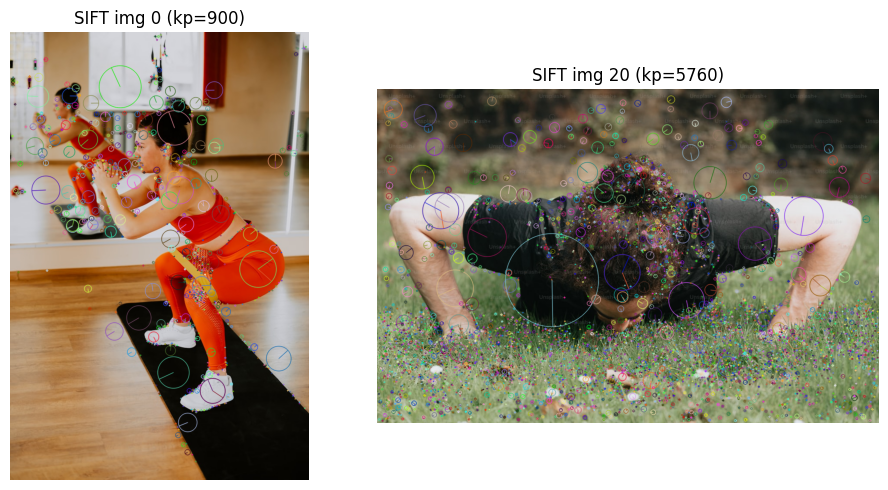

In [26]:
sift = cv2.SIFT_create()

images_gray = []
sift_desc_list = []
n_keypoints = []

for img_rgb in images_rgb:
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    images_gray.append(gray)
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    if descriptors is None:
        descriptors = np.zeros((0, 128), dtype=np.float32)

    sift_desc_list.append(descriptors.astype(np.float32))
    n_keypoints.append(len(keypoints))

print("Keypoints SIFT por imagen:", n_keypoints)

plt.figure(figsize=(10, 5))
for i, idx in enumerate([0, len(images_rgb) // 2]):
    img_kp = cv2.drawKeypoints(
        images_rgb[idx],
        sift.detect(images_gray[idx], None),
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    plt.subplot(1, 2, i + 1)
    plt.imshow(img_kp)
    plt.title(f"SIFT img {idx} (kp={n_keypoints[idx]})")
    plt.axis("off")

plt.tight_layout()
plt.show()

Bloques HOG por imagen: [225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225]


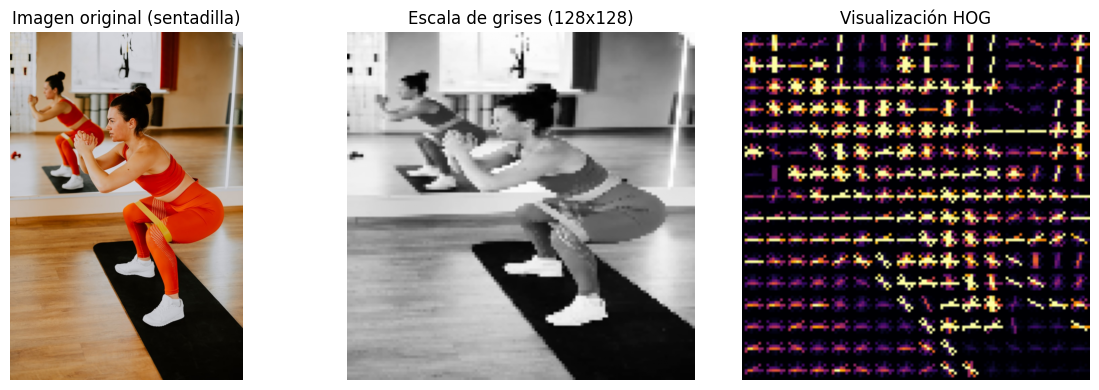

Forma de hog_desc_list[img_idx]: (225, 36)
Longitud del descriptor HOG global: 8100


array([[0.06303504, 0.04509472, 0.01741077, 0.01692246, 0.163724  ,
        0.04917865, 0.00758342, 0.01041473, 0.00660555, 0.31819895,
        0.02126832, 0.01053632, 0.00822855, 0.10876381, 0.02310157,
        0.0233922 , 0.00689399, 0.34451088, 0.2829297 , 0.01805369,
        0.12263347, 0.01366469, 0.34451088, 0.00562161, 0.15023085,
        0.00822855, 0.34451088, 0.34451088, 0.00132094, 0.00795055,
        0.08609601, 0.34451088, 0.08439555, 0.02229956, 0.06030725,
        0.34451088],
       [0.38385198, 0.03114193, 0.01542771, 0.01204857, 0.15925637,
        0.03382625, 0.03425181, 0.01009446, 0.38385198, 0.0155698 ,
        0.03200295, 0.07679515, 0.10235199, 0.1383155 , 0.01679822,
        0.00504371, 0.        , 0.        , 0.38385198, 0.00193417,
        0.01164151, 0.12606525, 0.38385198, 0.12357538, 0.03265191,
        0.08830431, 0.38385198, 0.00086499, 0.        , 0.02165008,
        0.08081258, 0.38385198, 0.03296563, 0.03840894, 0.00193417,
        0.        ],
      

In [ ]:
orientations = 9
cells_per_block = (2, 2)
hog_size = (128, 128)

hog_images = []
hog_desc_list = []
n_hog_blocks = []

for gray in images_gray:
    gray_resized = cv2.resize(gray, hog_size)
    hog_images.append(gray_resized)

    hog_blocks = hog(
        gray_resized,
        cells_per_block=cells_per_block,
        visualize=False
        )

    descriptors = hog_blocks.reshape(-1, np.prod(cells_per_block) * orientations).astype(np.float32)
    hog_desc_list.append(descriptors)
    n_hog_blocks.append(descriptors.shape[0])

print("Bloques HOG por imagen:", n_hog_blocks)

img_idx = 0
hog_features, hog_image = hog(
    hog_images[img_idx],
    orientations=orientations,
    cells_per_block=cells_per_block,
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True,
    channel_axis=None,
 )

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(images_rgb[img_idx])
plt.title(f"Imagen original ({labels[img_idx]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(hog_images[img_idx], cmap="gray")
plt.title("Escala de grises (128x128)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hog_image_rescaled, cmap="inferno")
plt.title("Visualización HOG")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Forma de hog_desc_list[img_idx]:", hog_desc_list[img_idx].shape)
print("Longitud del descriptor HOG global:", hog_features.shape[0])
hog_desc_list[img_idx][:5]

In [60]:
all_desc_by_extractor = {
    "sift": sift_desc_list,
    "hog": hog_desc_list,
}

extractor_for_kmeans = "sift"
all_desc_list = all_desc_by_extractor[extractor_for_kmeans]

y = np.array(labels)
image_indices = np.arange(len(y))
train_idx, test_idx, y_train, y_test = train_test_split(
    image_indices,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y,
)

train_desc_list = [all_desc_list[idx] for idx in train_idx]
test_desc_list = [all_desc_list[idx] for idx in test_idx]

print("Extractores disponibles:", list(all_desc_by_extractor.keys()))
print("Extractor seleccionado para k-means:", extractor_for_kmeans)
print("Forma del primer descriptor seleccionado:", all_desc_list[0].shape)
print("Imágenes de entrenamiento:", len(train_idx), "| Imágenes de prueba:", len(test_idx))

Extractores disponibles: ['sift', 'hog']
Extractor seleccionado para k-means: sift
Forma del primer descriptor seleccionado: (900, 128)
Imágenes de entrenamiento: 24 | Imágenes de prueba: 16


# Construcción de diccionario/vocabulario

In [61]:
desc_stack = [] # Reúne todos los descriptores del conjunto de entrenamiento

for desc in train_desc_list:

    if len(desc) > 400: # muestreo (máx 400 por imagen de entrenamiento)
        idx = np.random.choice(len(desc), 400, replace=False)
        desc = desc[idx]
    desc_stack.append(desc)

if len(desc_stack) == 0:
    raise RuntimeError("No hay descriptores de entrenamiento; revisa la extracción elegida.")

desc_stack = np.vstack(desc_stack).astype(np.float32)
print(f"Extractor usado: {extractor_for_kmeans}")
print("Descriptores totales de entrenamiento para k-means:", desc_stack.shape)

K = 40

kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=2048, n_init="auto")
kmeans.fit(desc_stack)

centers = kmeans.cluster_centers_
print("Diccionario visual entrenado. Centros shape:", centers.shape)
print("Justificación de K: se usa un valor intermedio adecuado para un conjunto pequeño, evitando un vocabulario demasiado pobre o demasiado disperso.")

Extractor usado: sift
Descriptores totales de entrenamiento para k-means: (9378, 128)
Diccionario visual entrenado. Centros shape: (40, 128)
Justificación de K: se usa un valor intermedio adecuado para un conjunto pequeño, evitando un vocabulario demasiado pobre o demasiado disperso.


# Cuantificación vectorial

Extractor usado para BoVW: sift
X total (BoVW): (40, 40)
X_train: (24, 40) | X_test: (16, 40) | K = 40


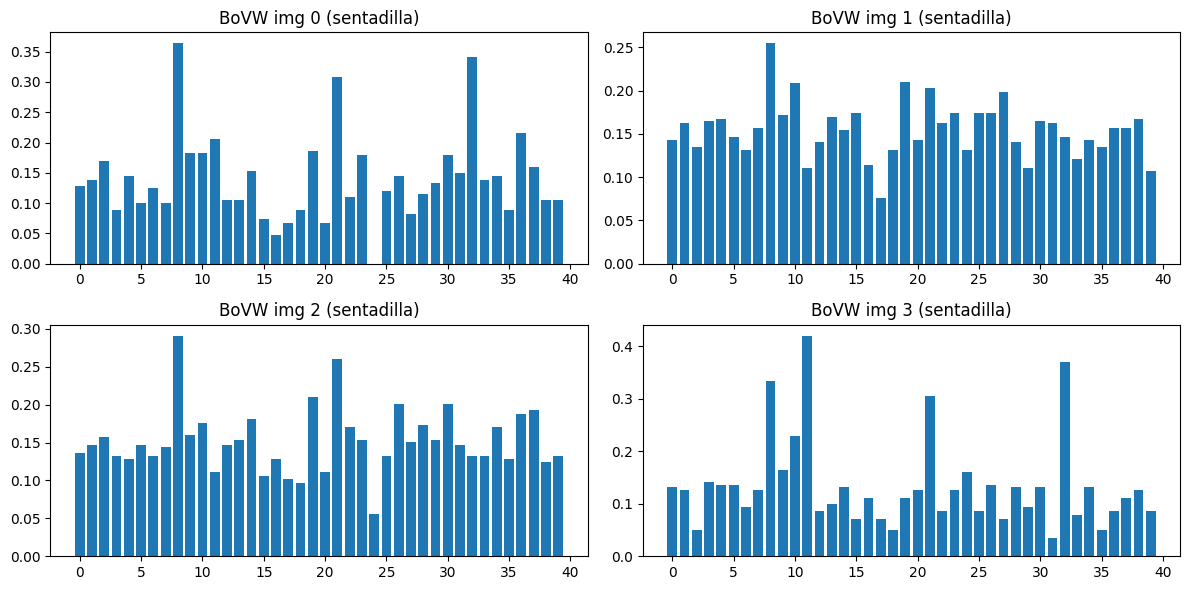

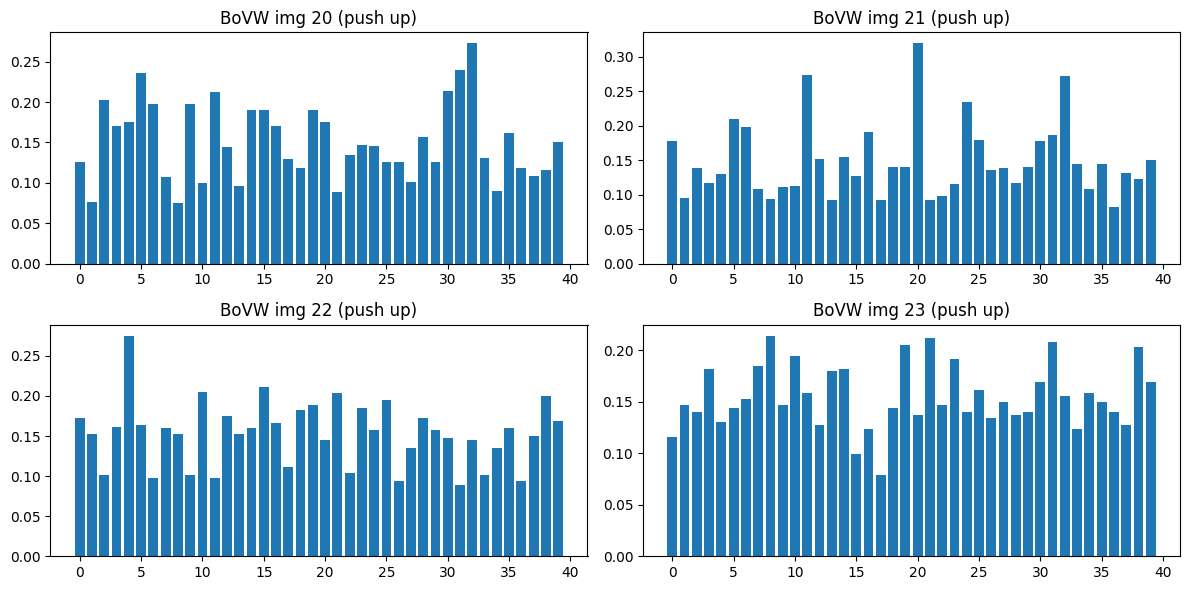

In [62]:
bovw_list = [] # Codifica cada imagen como histograma BoVW usando el diccionario aprendido en entrenamiento

for i, desc in enumerate(all_desc_list):
    if len(desc) == 0:

        hist = np.zeros(K, dtype=np.float32)
    else:
        word_ids = kmeans.predict(desc)
        hist = np.bincount(word_ids, minlength=K)
        hist = hist.astype(np.float32)

    hist = np.sqrt(hist)
    norm = np.linalg.norm(hist) + 1e-8
    hist = hist / norm

    bovw_list.append(hist)

X = np.vstack(bovw_list)
X_train = X[train_idx]
X_test = X[test_idx]

print(f"Extractor usado para BoVW: {extractor_for_kmeans}")
print("X total (BoVW):", X.shape)
print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| K =", K)

plt.figure(figsize=(12,6))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.bar(np.arange(K), X[i])
    plt.title(f"BoVW img {i} ({labels[i]})")
    plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
for j in range(4):
    idx = 20 + j
    plt.subplot(2,2,j+1)
    plt.bar(np.arange(K), X[idx])
    plt.title(f"BoVW img {idx} ({labels[idx]})")
    plt.tight_layout()
plt.show()

# Clasificación (Laboratorio)

Accuracy (SVM lineal): 62.50%

Reporte de clasificación:
               precision    recall  f1-score   support

     push up       0.75      0.38      0.50         8
  sentadilla       0.58      0.88      0.70         8

    accuracy                           0.62        16
   macro avg       0.67      0.62      0.60        16
weighted avg       0.67      0.62      0.60        16



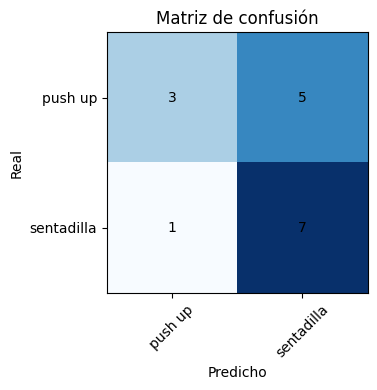

In [63]:
clf = LinearSVC(C=1.0, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy (SVM lineal):", f"{acc*100:.2f}%")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

classes = sorted(list(set(y)))
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Blues')
plt.title("Matriz de confusión")
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()